# Country-Level Profitability — Where Does Margin Actually Go?

`Q2_high_value_customers.ipynb` looked at countries through a customer-conversion lens (HV rate
vs. GDP). That answers "which markets have the richest customers," but not "which markets are
actually profitable to run." A country can have great customers and still be a weak market if
margin or profit-per-order is thin — and the discovery notes for Q1 already showed shipping fee
behavior swings profit per order a lot. This notebook asks directly:

1. Does **margin** (not just revenue or HV rate) actually vary by country?
2. Is **shipping cost structure** — the fee as a share of order value — eating into profit in
   some markets more than others?
3. Which countries need a different fix: a shipping/free-shipping problem vs. something else
   entirely?

**Setup:** if margin were roughly uniform across markets, country strategy would just be "go
where the volume is." If it isn't uniform, some markets are quietly worth less per order than
their size suggests, and the fix depends on *why*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-999, 999)

PLAIN = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
PCT = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}%")
MILLIONS = mticker.FuncFormatter(lambda x, pos: f"{x/1e6:,.0f}")

df = pd.read_csv("orders.csv", parse_dates=["Order_Date"])
df = df.dropna(subset=["Profit"])
df.shape

(665916, 11)

## 1. Country-level profitability table

Aggregate to the shipping-country level (shipping and billing country agree 99.998% of the time,
so shipping country is the cleaner single label). We restrict charts to the **top 15 countries
by order volume** — they cover 98.5% of orders and 98.6% of total profit, so the tail adds noise
without adding coverage.

In [2]:
g = df.groupby("Shipping_Country").agg(
    n_orders=("Order_ID", "size"),
    total_profit=("Profit", "sum"),
    total_revenue=("Total_amount_excl__VAT", "sum"),
    avg_margin=("Profit_margin", "mean"),
    avg_order_value=("Total_amount_excl__VAT", "mean"),
    avg_shipping_fee=("Shipping_fee_excl__VAT", "mean"),
).sort_values("n_orders", ascending=False)

top15 = g.head(15).copy()
top15["profit_per_order"] = top15["total_profit"] / top15["n_orders"]
top15["margin_pct"] = top15["avg_margin"] * 100
top15["shipping_pct_of_aov"] = top15["avg_shipping_fee"] / top15["avg_order_value"] * 100

print(f"Top 15 countries cover {top15['n_orders'].sum() / len(df) * 100:.1f}% of orders "
      f"and {top15['total_profit'].sum() / df['Profit'].sum() * 100:.1f}% of total profit")
top15[["n_orders", "total_profit", "profit_per_order", "margin_pct",
       "avg_order_value", "shipping_pct_of_aov"]].round(2)

Top 15 countries cover 98.5% of orders and 98.6% of total profit


,n_orders,total_profit,profit_per_order,margin_pct,avg_order_value,shipping_pct_of_aov
Shipping_Country,,,,,,
DE,150157,59960403.93,399.32,70.87,563.21,2.22
SE,108449,31589169.43,291.28,69.30,420.67,2.41
GB,76365,20737024.81,271.55,58.05,470.18,5.55
DK,50262,17088657.70,339.99,67.79,501.04,3.14
NL,50127,13849070.01,276.28,59.79,463.78,3.86
FR,40815,13940347.26,341.55,63.56,537.10,2.76
PL,35964,9095327.30,252.90,58.44,433.52,3.75
NO,30297,9072066.12,299.44,61.79,484.41,2.39
FI,22359,6169464.87,275.93,62.29,443.23,3.59


## 2. Margin varies a lot more than order volume would suggest

Ranking by order volume (as Q2 did) puts DE, SE and GB at the top. But margin tells a different
story — it ranges from **54.4% (US) to 70.9% (DE)**, a 16.5 point spread among markets that are
all sizeable, established parts of the business.

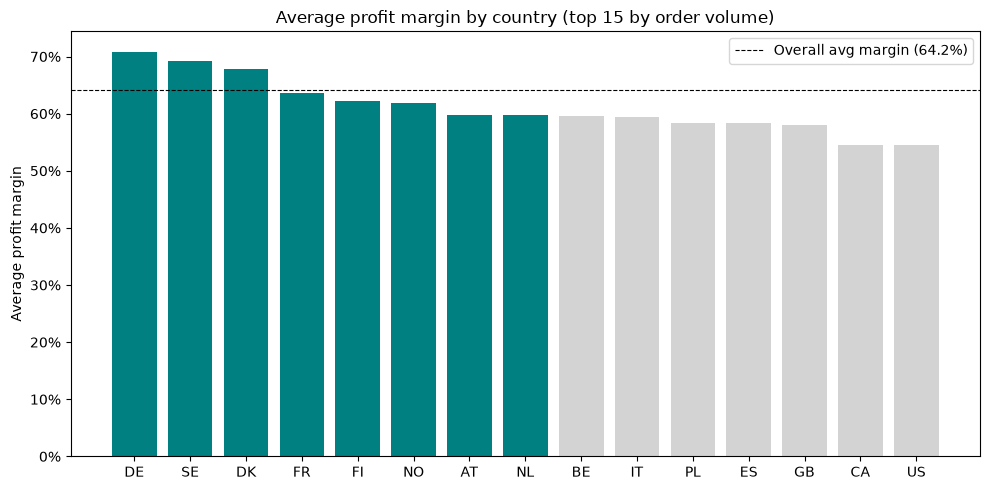

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ranked = top15["margin_pct"].sort_values(ascending=False)
colors = ["teal" if v >= ranked.median() else "lightgray" for v in ranked.values]
ax.bar(ranked.index, ranked.values, color=colors)
ax.axhline(df["Profit_margin"].mean() * 100, color="black", linewidth=0.8, linestyle="--",
           label=f"Overall avg margin ({df['Profit_margin'].mean() * 100:.1f}%)")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("Average profit margin")
ax.set_title("Average profit margin by country (top 15 by order volume)")
ax.legend()
fig.tight_layout()
plt.show()

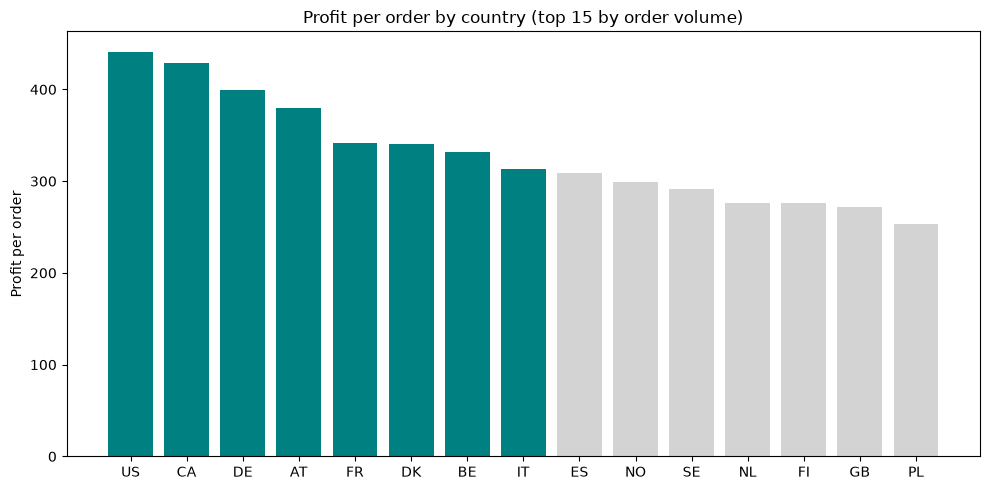

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ranked = top15["profit_per_order"].sort_values(ascending=False)
colors = ["teal" if v >= ranked.median() else "lightgray" for v in ranked.values]
ax.bar(ranked.index, ranked.values, color=colors)
ax.yaxis.set_major_formatter(PLAIN)
ax.set_ylabel("Profit per order")
ax.set_title("Profit per order by country (top 15 by order volume)")
fig.tight_layout()
plt.show()

**Conflict:** volume and margin don't line up. DE and SE — the two biggest markets — also
carry the two highest margins (70.9%, 69.3%), which is good news. But GB, the **3rd**-biggest
market by volume, has the **3rd-lowest** margin (58.1%) and the lowest profit-per-order of any
major market (€271, vs. €399 for DE). And the two North American markets, US and CA, have by far
the highest average order value (€811, €788) yet the two lowest margins in the group (54.4%,
54.5%) — high revenue per order does not mean high profit per order there.

## 3. Is shipping cost structure the explanation?

The hypothesis: markets where the shipping fee eats a bigger share of order value should have
thinner margins. Check it directly with `shipping_pct_of_aov` = avg shipping fee / avg order
value.

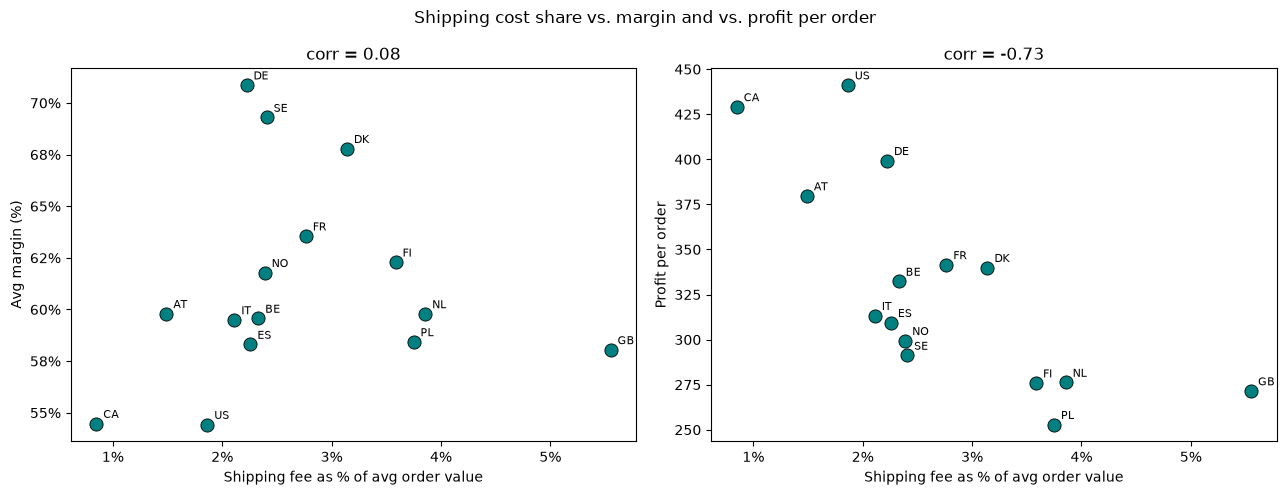

corr(shipping_pct_of_aov, margin_pct): 0.08
corr(shipping_pct_of_aov, profit_per_order): -0.73


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, ycol, ylabel, fmt in [
    (axes[0], "margin_pct", "Avg margin (%)", PCT),
    (axes[1], "profit_per_order", "Profit per order", PLAIN),
]:
    ax.scatter(top15["shipping_pct_of_aov"], top15[ycol], s=90, color="teal",
               edgecolors="black", linewidths=0.6, zorder=3)
    for country, row in top15.iterrows():
        ax.annotate(country, (row["shipping_pct_of_aov"], row[ycol]),
                     textcoords="offset points", xytext=(5, 4), fontsize=8)
    corr = top15["shipping_pct_of_aov"].corr(top15[ycol])
    ax.set_xlabel("Shipping fee as % of avg order value")
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(fmt)
    ax.xaxis.set_major_formatter(PCT)
    ax.set_title(f"corr = {corr:.2f}")

fig.suptitle("Shipping cost share vs. margin and vs. profit per order")
fig.tight_layout()
plt.show()

print("corr(shipping_pct_of_aov, margin_pct):", round(top15["shipping_pct_of_aov"].corr(top15["margin_pct"]), 2))
print("corr(shipping_pct_of_aov, profit_per_order):", round(top15["shipping_pct_of_aov"].corr(top15["profit_per_order"]), 2))

**Finding — the two right-hand-side metrics tell different stories:**

- **Margin % is basically uncorrelated with shipping cost share (corr = 0.08).** This isn't a
  coincidence: in this data `Profit = Total_amount_excl_VAT × Profit_margin` exactly (verified
  directly, residual ~0 to floating-point error), and `Total_amount_excl_VAT` already includes
  the shipping fee as revenue. So `Profit_margin` is applied as a flat rate to the whole order
  — it isn't a residual left over after subtracting a separate shipping cost. A country can have
  a high shipping fee and a high margin at the same time (or vice versa) because the two aren't
  mechanically linked in how this field is constructed.
- **Profit per order is strongly correlated with shipping cost share (corr = -0.73).** This
  works through order size, not margin: shipping fee is a bigger fraction of the basket in
  countries with smaller average orders, and smaller orders simply produce less profit in
  absolute terms. So shipping cost share is a **symptom of small-basket markets**, not a direct
  cause of low margin.

That reframes the question: GB and the US/CA pair both look "unprofitable" relative to their
size, but for two different, unrelated reasons.

## 4. GB: a free-shipping conversion problem, consistent with the Q1 finding

Q1 established that free-shipping orders are far more valuable per order than paid-shipping
ones. If GB simply converts fewer customers to free shipping than peers like DE, that alone
would explain a chunk of its underperformance.

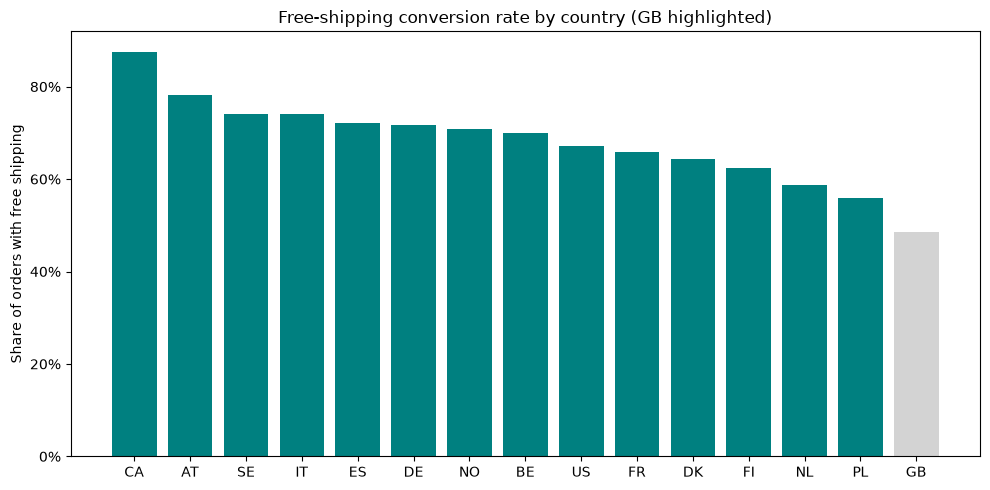

Shipping_Country
CA    87.6
AT    78.2
SE    74.2
IT    74.0
ES    72.1
DE    71.7
NO    70.9
BE    70.0
US    67.2
FR    65.9
DK    64.4
FI    62.3
NL    58.6
PL    55.9
GB    48.6
Name: free_ship, dtype: float64


In [6]:
df["free_ship"] = df["Shipping_fee_excl__VAT"] == 0
free_ship_rate = df.groupby("Shipping_Country")["free_ship"].mean().reindex(top15.index) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ranked = free_ship_rate.sort_values(ascending=False)
colors = ["lightgray" if c == "GB" else "teal" for c in ranked.index]
ax.bar(ranked.index, ranked.values, color=colors)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("Share of orders with free shipping")
ax.set_title("Free-shipping conversion rate by country (GB highlighted)")
fig.tight_layout()
plt.show()

print(ranked.round(1))

In [7]:
for c in ["GB", "DE"]:
    sub = df[df["Shipping_Country"] == c]
    stats = sub.groupby("free_ship").agg(
        n=("Order_ID", "size"),
        avg_margin_pct=("Profit_margin", lambda s: s.mean() * 100),
        avg_profit=("Profit", "mean"),
    )
    print(f"--- {c} ---")
    print(stats.round(2), "\n")

gb = top15.loc["GB"]
de_margin = top15.loc["DE", "margin_pct"] / 100
gb_margin_gap_profit = gb["total_revenue"] * (de_margin - gb["avg_margin"])
print(f"GB profit if it carried DE's margin instead of its own: "
      f"+{gb_margin_gap_profit:,.0f} ({gb_margin_gap_profit / gb['total_profit'] * 100:.1f}% "
      f"uplift on GB's current profit)")

--- GB ---
               n  avg_margin_pct  avg_profit
free_ship                                   
False      39271           58.53      150.48
True       37094           57.54      399.73 

--- DE ---
                n  avg_margin_pct  avg_profit
free_ship                                    
False       42524           70.86      173.17
True       107633           70.87      488.67 

GB profit if it carried DE's margin instead of its own: +4,603,141 (22.2% uplift on GB's current profit)


**GB detail confirms the Q1 pattern applies here too, but doesn't fully explain the margin
gap:**

- GB's free-shipping rate is **48.6%** — the lowest of any major market, well below DE (71.7%)
  and SE (74.2%).
- Within GB, free-shipping orders average **€400 profit vs. €150 for paid-shipping orders** — a
  2.7x gap, matching the general Q1 pattern. So converting more GB customers to free shipping
  (the intervention already recommended off Q1) would lift GB's profit-per-order specifically.
- But margin % is nearly flat within GB regardless of shipping status (58.5% free vs. 57.5%
  paid) — and also flat within DE (70.9% vs. 70.9%). So the **16.5-point margin gap between GB
  and DE is not a free-shipping mix effect** — it's a separate, country-level margin baseline
  that free-shipping conversion won't close. If GB's margin rate matched DE's, that alone is
  worth **~€4.6M**, a 22% uplift on GB's current profit — on top of, not instead of, the
  free-shipping conversion opportunity.

## 5. US / CA: a different problem — high order value, structurally thin margin

US and CA have the **highest** average order values in the top 15 (€811, €788) and among the
**lowest** shipping-cost shares (1.9%, 0.8% of AOV — the opposite of GB). If shipping cost isn't
the driver, their low margin (54.4%, 54.5%) must come from something else the data can point at
but not fully explain — most likely product mix or a different cost basis for
North America.

In [8]:
compare_cols = ["avg_order_value", "shipping_pct_of_aov", "margin_pct", "profit_per_order"]
snapshot = top15.loc[["DE", "GB", "US", "CA"], compare_cols].round(2)
snapshot.columns = ["Avg order value", "Shipping % of AOV", "Margin %", "Profit per order"]
snapshot

,Avg order value,Shipping % of AOV,Margin %,Profit per order
Shipping_Country,,,,
DE,563.21,2.22,70.87,399.32
GB,470.18,5.55,58.05,271.55
US,811.08,1.86,54.43,441.25
CA,788.42,0.85,54.48,429.16


US and CA earn nearly double DE's revenue per order but keep a smaller share of it as
profit, and it isn't because shipping is expensive for them — it's the opposite. That rules out
the GB-style fix (push free shipping / cut effective shipping cost) and points instead at
**what's actually being sold or sourced in North America** — a question this dataset (no
product-category or COGS field) can't answer directly, but is worth a scoped follow-up with
whoever owns NA merchandising or fulfillment cost.

## Summary

**Setup:** Q2 ranked countries by HV-customer conversion. This notebook asks the more direct
question — which markets are actually profitable, and if some aren't, why.

**Conflict / findings:**
- **Margin genuinely varies by country**, from 54.4% (US) to 70.9% (DE) among the top 15 markets
  — a 16.5-point spread that order-volume ranking completely hides.
- **Shipping cost share (fee / order value) explains profit-per-order (corr -0.73) but not
  margin (corr 0.08).** `Profit_margin` is applied as a flat rate to total order value in this
  data, so it isn't mechanically reduced by a high shipping fee — the two effects are separate
  and need separate fixes.
- **GB** is the weakest major market: lowest free-shipping conversion (48.6% vs. 71-74% for
  DE/SE) *and* the 3rd-lowest margin. The free-shipping gap alone reproduces the Q1
  pattern (2.7x profit per order, free vs. paid) inside GB; closing the separate margin gap to
  DE's level is worth an estimated **+€4.6M (+22%)** on top of that.
- **US and CA** are a different failure mode: highest order values, lowest shipping-cost
  burden, but the two lowest margins in the group. Shipping isn't the cause here — it looks
  like a structural cost or product-mix issue specific to North America.

**Resolution:** country strategy needs two separate playbooks, not one. For GB, extend the
free-shipping-conversion push from Q1's recommendation specifically to that market, and
separately investigate why GB's underlying margin rate trails DE/SE by ~16 points even after
controlling for shipping mix. For US/CA, shipping-side interventions won't move the needle —
the next step is a cost/product-mix review with the NA team, outside what this dataset alone can
diagnose.